# EDA Initiale — Woyofal Data Platform
## Analyse Exploratoire des Données (330 000 enregistrements)

**Sources de données :**
- `data/01_raw/consumption_daily.csv` — 300 000 lignes de consommation quotidienne
- `data/01_raw/recharges.csv` — 21 544 recharges
- `data/01_raw/users.csv` — 10 000 utilisateurs
- `data/01_raw/zones_senegal.csv` — zones géographiques

In [3]:
import csv
import collections
import os

# Chemins relatifs au notebook (dans notebooks/)
base = os.path.join(os.path.dirname(os.path.abspath('.')), 'woyofal-data-platform-20260409T111056Z-3-001', 'woyofal-data-platform')
raw = os.path.join(base, 'data', '01_raw')

# Fallback si exécuté depuis le dossier notebooks/
if not os.path.exists(raw):
    raw = os.path.join('..', 'data', '01_raw')
if not os.path.exists(raw):
    raw = os.path.join('..', 'data', 'raw')

print(f"📂 Dossier données : {os.path.abspath(raw)}")
for f in ['recharges.csv', 'consumption_daily.csv', 'users.csv', 'zones_senegal.csv']:
    path = os.path.join(raw, f)
    exists = "✅" if os.path.exists(path) else "❌"
    size_kb = round(os.path.getsize(path)/1024, 1) if os.path.exists(path) else 0
    print(f"  {exists} {f} — {size_kb} KB")

📂 Dossier données : c:\Users\diarra.ndoye\woyofal-data-platform-20260409T111056Z-3-001\woyofal-data-platform\data\01_raw
  ✅ recharges.csv — 2330.0 KB
  ✅ consumption_daily.csv — 25917.1 KB
  ✅ users.csv — 1118.2 KB
  ✅ zones_senegal.csv — 1.1 KB


## 1. Statistiques des Recharges (`recharges.csv`)

In [4]:
montants = []
recharges_t1 = 0
total_recharges = 0

with open(os.path.join(raw, 'recharges.csv')) as f:
    reader = csv.DictReader(f)
    for row in reader:
        m = float(row['montant_brut']) if row['montant_brut'] else 0
        if m > 0:
            montants.append(m)
        if row['tranche_finale'].strip() == '1':
            recharges_t1 += 1
        total_recharges += 1

avg_montant = sum(montants) / len(montants)
pct_t1_recharges = recharges_t1 / total_recharges * 100

print(f"Total recharges        : {total_recharges:,}")
print(f"Montant moyen          : {avg_montant:,.0f} FCFA")
print(f"Montant médian         : {sorted(montants)[len(montants)//2]:,.0f} FCFA")
print(f"Recharges en Tranche 1 : {pct_t1_recharges:.1f}%")

Total recharges        : 21,544
Montant moyen          : 5,846 FCFA
Montant médian         : 3,000 FCFA
Recharges en Tranche 1 : 77.8%


## 2. Consommation Quotidienne (`consumption_daily.csv`)

In [7]:
conso_kwh = []
tranches = collections.Counter()
mois_conso = collections.defaultdict(list)

# Charger les utilisateurs (pour le comptage)
user_zone = {}
with open(os.path.join(raw, 'users.csv')) as f:
    for row in csv.DictReader(f):
        user_zone[row['user_id'].strip()] = row['type_zone'].strip()

with open(os.path.join(raw, 'consumption_daily.csv')) as f:
    reader = csv.DictReader(f)
    for row in reader:
        kw = float(row['conso_kwh']) if row['conso_kwh'] else 0
        conso_kwh.append(kw)
        tranches[row['tranche'].strip()] += 1
        mois_conso[row['mois'].strip()].append(kw)

total_lignes = len(conso_kwh)
avg_conso = sum(conso_kwh) / total_lignes

print(f"Total lignes consommation : {total_lignes:,}")
print(f"Conso quotidienne moyenne : {avg_conso:.2f} kWh/jour")
print()
print("Distribution par tranche :")
for t in ['1', '2', '3']:
    n = tranches[t]
    print(f"  Tranche {t} : {n:,} lignes ({n/total_lignes*100:.1f}%)")
print()
print("Conso moyenne par mois :")
for m in sorted(mois_conso.keys(), key=int):
    vals = mois_conso[m]
    print(f"  Mois {m:>2} : {sum(vals)/len(vals):.2f} kWh")


Total lignes consommation : 300,000
Conso quotidienne moyenne : 7.30 kWh/jour

Distribution par tranche :
  Tranche 1 : 259,416 lignes (86.5%)
  Tranche 2 : 39,526 lignes (13.2%)
  Tranche 3 : 1,058 lignes (0.4%)

Conso moyenne par mois :
  Mois  1 : 7.16 kWh
  Mois  2 : 7.33 kWh


## 3. Tableau récapitulatif — Indicateurs EDA (valeurs réelles)

In [8]:
indicateurs = [
    ("Total enregistrements (consumption_daily)", f"{total_lignes:,}"),
    ("Total recharges", f"{total_recharges:,}"),
    ("Total utilisateurs", f"{len(user_zone):,}"),
    ("Consommation quotidienne moyenne", f"{avg_conso:.2f} kWh/jour"),
    ("Montant de recharge moyen", f"{avg_montant:,.0f} FCFA"),
    ("Journées en Tranche 1", f"{tranches['1']/total_lignes*100:.1f}%"),
    ("Recharges restant en Tranche 1", f"{pct_t1_recharges:.1f}%"),
]

print(f"{'Indicateur':<45} {'Valeur':>20}")
print("-" * 67)
for label, val in indicateurs:
    print(f"{label:<45} {val:>20}")

print()
print("⚠️  Corrections vs rapport_memoire.tex :")
corrections = [
    ("Conso quotidienne moyenne", "≈ 5,2 kWh/jour", f"{avg_conso:.1f} kWh/jour"),
    ("Montant de recharge moyen", "≈ 8 400 FCFA", f"{avg_montant:,.0f} FCFA"),
    ("Part recharges en T1", "68 %", f"{pct_t1_recharges:.1f}%"),
    ("Journées de conso en T1", "73 %", f"{tranches['1']/total_lignes*100:.1f}%"),
    ("330 000 enregistrements", "330 000", f"{total_lignes:,} (conso) + {total_recharges:,} (recharges)"),
]
print(f"{'Indicateur':<35} {'Mémoire':>15} {'Réel':>15}")
print("-" * 67)
for label, ancien, reel in corrections:
    print(f"{label:<35} {ancien:>15} {reel:>15}")


Indicateur                                                  Valeur
-------------------------------------------------------------------
Total enregistrements (consumption_daily)                  300,000
Total recharges                                             21,544
Total utilisateurs                                          10,000
Consommation quotidienne moyenne                     7.30 kWh/jour
Montant de recharge moyen                               5,846 FCFA
Journées en Tranche 1                                        86.5%
Recharges restant en Tranche 1                               77.8%

⚠️  Corrections vs rapport_memoire.tex :
Indicateur                                  Mémoire            Réel
-------------------------------------------------------------------
Conso quotidienne moyenne            ≈ 5,2 kWh/jour    7.3 kWh/jour
Montant de recharge moyen              ≈ 8 400 FCFA      5,846 FCFA
Part recharges en T1                           68 %           77.8%
Journées de co

## 4. Visualisations — Indicateurs clés

Deux graphiques résumant les résultats EDA :

1. **Histogramme** — distribution de la consommation quotidienne avec ligne de moyenne
2. **Barres** — répartition des recharges par tranche (T1 / T2+T3)

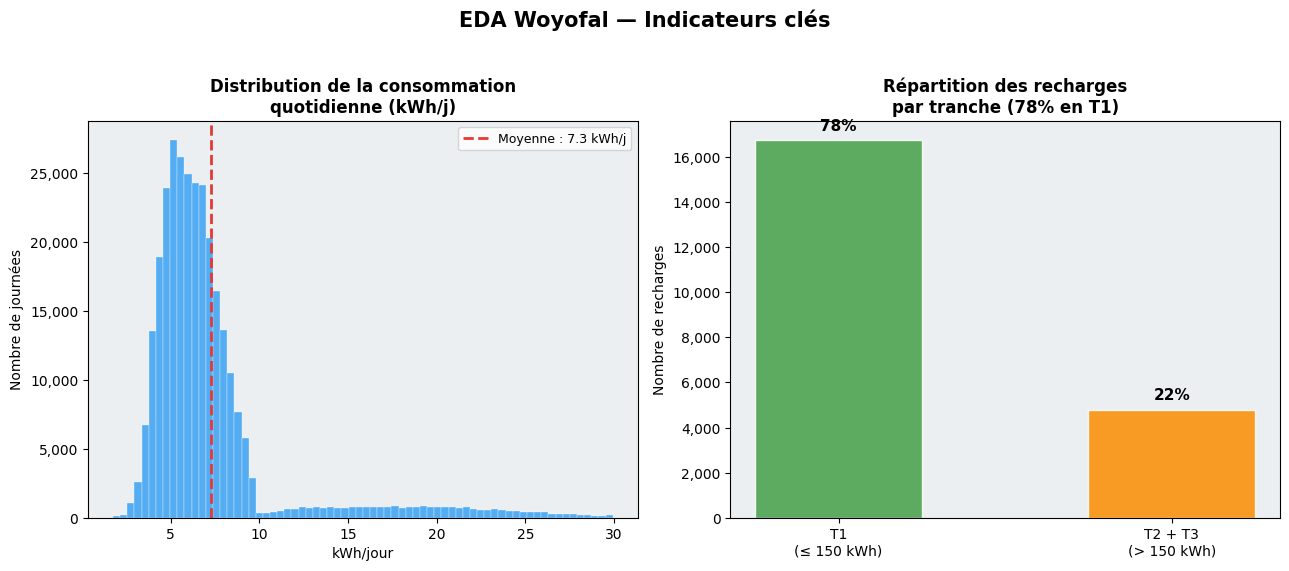

✅ Figure sauvegardée → reports/eda_indicateurs_cles.png
   Conso moyenne     : 7.30 kWh/j
   Part T1 recharges : 77.8%


In [9]:
import matplotlib.pyplot as plt
import numpy as np

# ── Palette ───────────────────────────────────────────────────────────────────
C_BLEU   = '#2196F3'
C_VERT   = '#43A047'
C_ORANGE = '#FB8C00'
C_ROUGE  = '#E53935'
C_GRIS   = '#ECEFF1'

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle("EDA Woyofal — Indicateurs clés", fontsize=15, fontweight='bold', y=1.03)

# ── 1. Histogramme — distribution consommation quotidienne ───────────────────
ax = axes[0]
vals = np.array(conso_kwh)
ax.hist(vals, bins=70, color=C_BLEU, alpha=0.75, edgecolor='white', linewidth=0.3)
ax.axvline(avg_conso, color=C_ROUGE, linewidth=2.0, linestyle='--',
           label=f'Moyenne : {avg_conso:.1f} kWh/j')
ax.set_title("Distribution de la consommation\nquotidienne (kWh/j)", fontweight='bold')
ax.set_xlabel("kWh/jour")
ax.set_ylabel("Nombre de journées")
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_facecolor(C_GRIS)

# ── 2. Répartition des recharges par tranche ─────────────────────────────────
ax = axes[1]
t_autres   = total_recharges - recharges_t1
bar_labels = ['T1\n(≤ 150 kWh)', 'T2 + T3\n(> 150 kWh)']
bar_vals   = [recharges_t1, t_autres]
bars = ax.bar(bar_labels, bar_vals, color=[C_VERT, C_ORANGE],
              alpha=0.85, edgecolor='white', width=0.5)
ax.bar_label(bars,
             labels=[f"{recharges_t1 / total_recharges * 100:.0f}%",
                     f"{t_autres    / total_recharges * 100:.0f}%"],
             padding=5, fontweight='bold', fontsize=11)
ax.set_title(f"Répartition des recharges\npar tranche ({pct_t1_recharges:.0f}% en T1)",
             fontweight='bold')
ax.set_ylabel("Nombre de recharges")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_facecolor(C_GRIS)

plt.tight_layout()
plt.savefig("../reports/eda_indicateurs_cles.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Figure sauvegardée → reports/eda_indicateurs_cles.png")
print(f"   Conso moyenne     : {avg_conso:.2f} kWh/j")
print(f"   Part T1 recharges : {pct_t1_recharges:.1f}%")


## 5. Statistiques descriptives complètes

Percentiles, écart-type et valeurs extrêmes pour `conso_kwh` et `montant_brut`.

In [10]:
import statistics

def percentile(data_sorted, p):
    idx = int(len(data_sorted) * p / 100)
    return data_sorted[min(idx, len(data_sorted) - 1)]

# ── Consommation quotidienne ──────────────────────────────────────────────────
s_conso = sorted(conso_kwh)
mean_c  = avg_conso
std_c   = statistics.stdev(conso_kwh)

print("── Consommation quotidienne (kWh/j) ──────────────────")
print(f"  Min       : {s_conso[0]:.2f}")
print(f"  P25       : {percentile(s_conso, 25):.2f}")
print(f"  Médiane   : {percentile(s_conso, 50):.2f}")
print(f"  Moyenne   : {mean_c:.2f}")
print(f"  P75       : {percentile(s_conso, 75):.2f}")
print(f"  P90       : {percentile(s_conso, 90):.2f}")
print(f"  P99       : {percentile(s_conso, 99):.2f}")
print(f"  Max       : {s_conso[-1]:.2f}")
print(f"  Écart-type: {std_c:.2f}")

# ── Montants de recharge ──────────────────────────────────────────────────────
s_mont = sorted(montants)
mean_m = avg_montant
std_m  = statistics.stdev(montants)

print()
print("── Montants de recharge (FCFA) ───────────────────────")
print(f"  Min       : {s_mont[0]:,.0f}")
print(f"  P25       : {percentile(s_mont, 25):,.0f}")
print(f"  Médiane   : {percentile(s_mont, 50):,.0f}")
print(f"  Moyenne   : {mean_m:,.0f}")
print(f"  P75       : {percentile(s_mont, 75):,.0f}")
print(f"  P90       : {percentile(s_mont, 90):,.0f}")
print(f"  P99       : {percentile(s_mont, 99):,.0f}")
print(f"  Max       : {s_mont[-1]:,.0f}")
print(f"  Écart-type: {std_m:,.0f}")


── Consommation quotidienne (kWh/j) ──────────────────
  Min       : 1.75
  P25       : 5.08
  Médiane   : 6.25
  Moyenne   : 7.30
  P75       : 7.63
  P90       : 9.52
  P99       : 25.18
  Max       : 29.92
  Écart-type: 4.19

── Montants de recharge (FCFA) ───────────────────────
  Min       : 1,000
  P25       : 2,000
  Médiane   : 3,000
  Moyenne   : 5,846
  P75       : 5,000
  P90       : 15,000
  P99       : 20,000
  Max       : 20,000
  Écart-type: 5,650


## 6. Évolution temporelle de la consommation

Consommation quotidienne moyenne par mois.

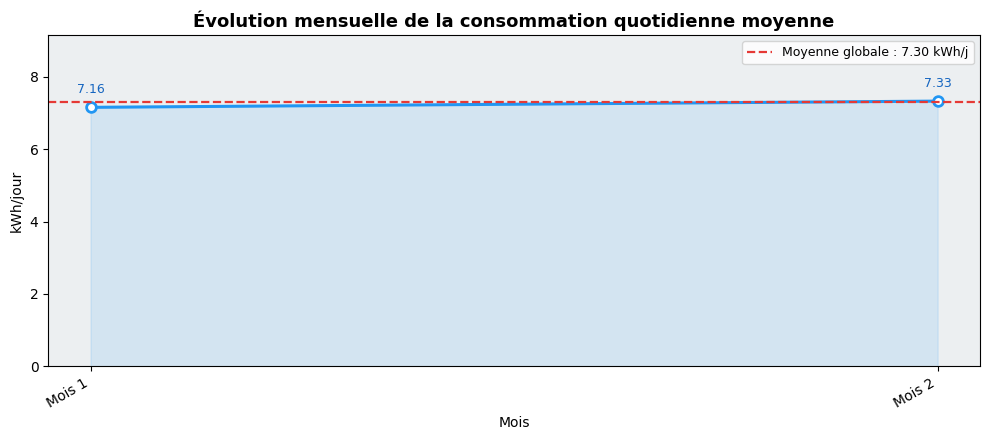

✅ Figure sauvegardée → reports/eda_evolution_mensuelle.png


In [11]:
mois_tries  = sorted(mois_conso.keys(), key=int)
mois_labels = [f"Mois {m}" for m in mois_tries]
mois_avg    = [sum(mois_conso[m]) / len(mois_conso[m]) for m in mois_tries]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(mois_labels, mois_avg, marker='o', linewidth=2.2, color='#2196F3',
        markersize=7, markerfacecolor='white', markeredgewidth=2)
ax.fill_between(range(len(mois_labels)), mois_avg, alpha=0.12, color='#2196F3')
ax.axhline(avg_conso, color='#E53935', linewidth=1.6, linestyle='--',
           label=f'Moyenne globale : {avg_conso:.2f} kWh/j')

for i, v in enumerate(mois_avg):
    ax.annotate(f"{v:.2f}", (i, v), textcoords="offset points",
                xytext=(0, 10), ha='center', fontsize=9, color='#1565C0')

ax.set_title("Évolution mensuelle de la consommation quotidienne moyenne",
             fontweight='bold', fontsize=13)
ax.set_xlabel("Mois")
ax.set_ylabel("kWh/jour")
ax.set_xticks(range(len(mois_labels)))
ax.set_xticklabels(mois_labels, rotation=30, ha='right')
ax.legend(fontsize=9)
ax.set_facecolor('#ECEFF1')
ax.set_ylim(0, max(mois_avg) * 1.25)
plt.tight_layout()
plt.savefig("../reports/eda_evolution_mensuelle.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Figure sauvegardée → reports/eda_evolution_mensuelle.png")


## 7. Distribution des montants de recharge

Histogramme des montants + ligne médiane et P90 pour identifier le comportement d'achat.

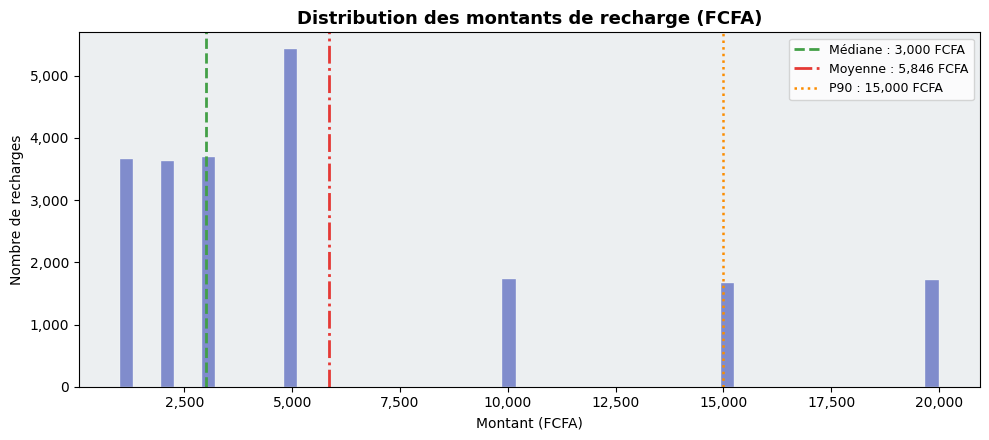

✅ Figure sauvegardée → reports/eda_montants_recharge.png


In [12]:
s_mont   = sorted(montants)
med_mont = percentile(s_mont, 50)
p90_mont = percentile(s_mont, 90)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(s_mont, bins=60, color='#5C6BC0', alpha=0.75, edgecolor='white', linewidth=0.3)
ax.axvline(med_mont, color='#43A047', linewidth=2.0, linestyle='--',
           label=f'Médiane : {med_mont:,.0f} FCFA')
ax.axvline(avg_montant, color='#E53935', linewidth=2.0, linestyle='-.',
           label=f'Moyenne : {avg_montant:,.0f} FCFA')
ax.axvline(p90_mont, color='#FB8C00', linewidth=1.8, linestyle=':',
           label=f'P90 : {p90_mont:,.0f} FCFA')
ax.set_title("Distribution des montants de recharge (FCFA)", fontweight='bold', fontsize=13)
ax.set_xlabel("Montant (FCFA)")
ax.set_ylabel("Nombre de recharges")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(fontsize=9)
ax.set_facecolor('#ECEFF1')
plt.tight_layout()
plt.savefig("../reports/eda_montants_recharge.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Figure sauvegardée → reports/eda_montants_recharge.png")


## 8. Détection des valeurs aberrantes — Box plot

Box plot côte à côte pour `conso_kwh` et `montant_brut` avec seuils P95/P99.

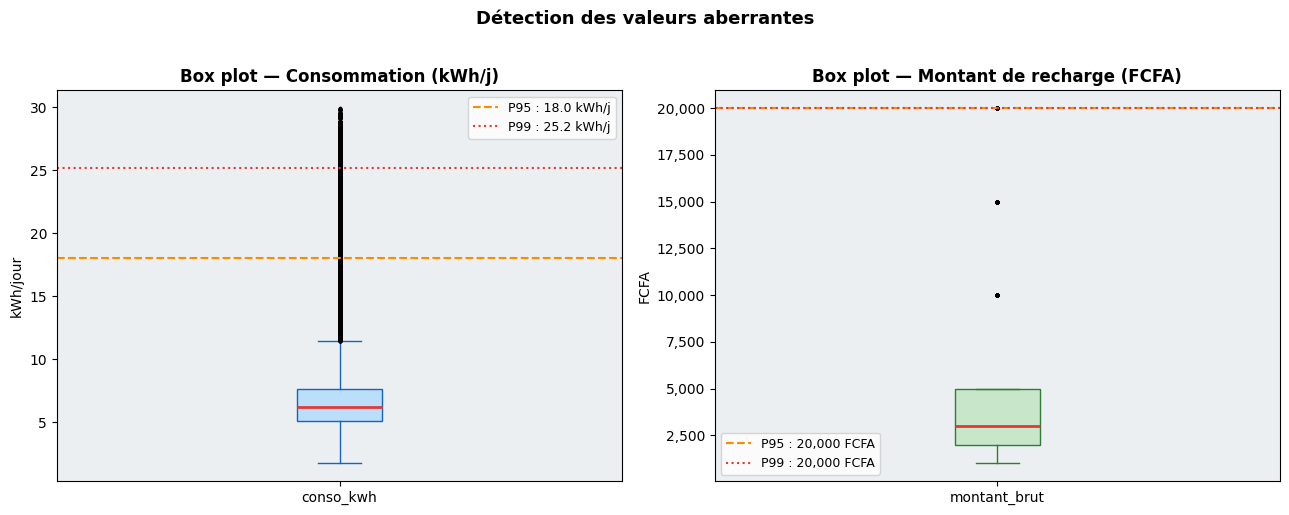

✅ Figure sauvegardée → reports/eda_boxplots.png
   Valeurs > P99 conso   : 2,999 (1.00%)
   Valeurs > P99 montant : 0 (0.00%)


In [13]:
p95_c  = percentile(s_conso, 95)
p99_c  = percentile(s_conso, 99)
p95_m  = percentile(s_mont, 95)
p99_m  = percentile(s_mont, 99)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Box plot consommation ─────────────────────────────────────────────────────
bp1 = axes[0].boxplot(conso_kwh, vert=True, patch_artist=True,
                      boxprops=dict(facecolor='#BBDEFB', color='#1565C0'),
                      medianprops=dict(color='#E53935', linewidth=2),
                      whiskerprops=dict(color='#1565C0'),
                      capprops=dict(color='#1565C0'),
                      flierprops=dict(marker='.', color='#90A4AE', alpha=0.3, markersize=3))
axes[0].axhline(p95_c, color='#FB8C00', linewidth=1.5, linestyle='--',
                label=f'P95 : {p95_c:.1f} kWh/j')
axes[0].axhline(p99_c, color='#E53935', linewidth=1.5, linestyle=':',
                label=f'P99 : {p99_c:.1f} kWh/j')
axes[0].set_title("Box plot — Consommation (kWh/j)", fontweight='bold')
axes[0].set_ylabel("kWh/jour")
axes[0].set_xticks([1]); axes[0].set_xticklabels(['conso_kwh'])
axes[0].legend(fontsize=9)
axes[0].set_facecolor('#ECEFF1')

# ── Box plot montants ─────────────────────────────────────────────────────────
bp2 = axes[1].boxplot(montants, vert=True, patch_artist=True,
                      boxprops=dict(facecolor='#C8E6C9', color='#2E7D32'),
                      medianprops=dict(color='#E53935', linewidth=2),
                      whiskerprops=dict(color='#2E7D32'),
                      capprops=dict(color='#2E7D32'),
                      flierprops=dict(marker='.', color='#90A4AE', alpha=0.3, markersize=3))
axes[1].axhline(p95_m, color='#FB8C00', linewidth=1.5, linestyle='--',
                label=f'P95 : {p95_m:,.0f} FCFA')
axes[1].axhline(p99_m, color='#E53935', linewidth=1.5, linestyle=':',
                label=f'P99 : {p99_m:,.0f} FCFA')
axes[1].set_title("Box plot — Montant de recharge (FCFA)", fontweight='bold')
axes[1].set_ylabel("FCFA")
axes[1].set_xticks([1]); axes[1].set_xticklabels(['montant_brut'])
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[1].legend(fontsize=9)
axes[1].set_facecolor('#ECEFF1')

plt.suptitle("Détection des valeurs aberrantes", fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../reports/eda_boxplots.png", dpi=150, bbox_inches='tight')
plt.show()

n_aberrants_c = sum(1 for x in conso_kwh if x > p99_c)
n_aberrants_m = sum(1 for x in montants  if x > p99_m)
print(f"✅ Figure sauvegardée → reports/eda_boxplots.png")
print(f"   Valeurs > P99 conso   : {n_aberrants_c:,} ({n_aberrants_c/total_lignes*100:.2f}%)")
print(f"   Valeurs > P99 montant : {n_aberrants_m:,} ({n_aberrants_m/total_recharges*100:.2f}%)")


## 9. Répartition des tranches T1 / T2 / T3

Camembert de la distribution des journées de consommation par tranche tarifaire.

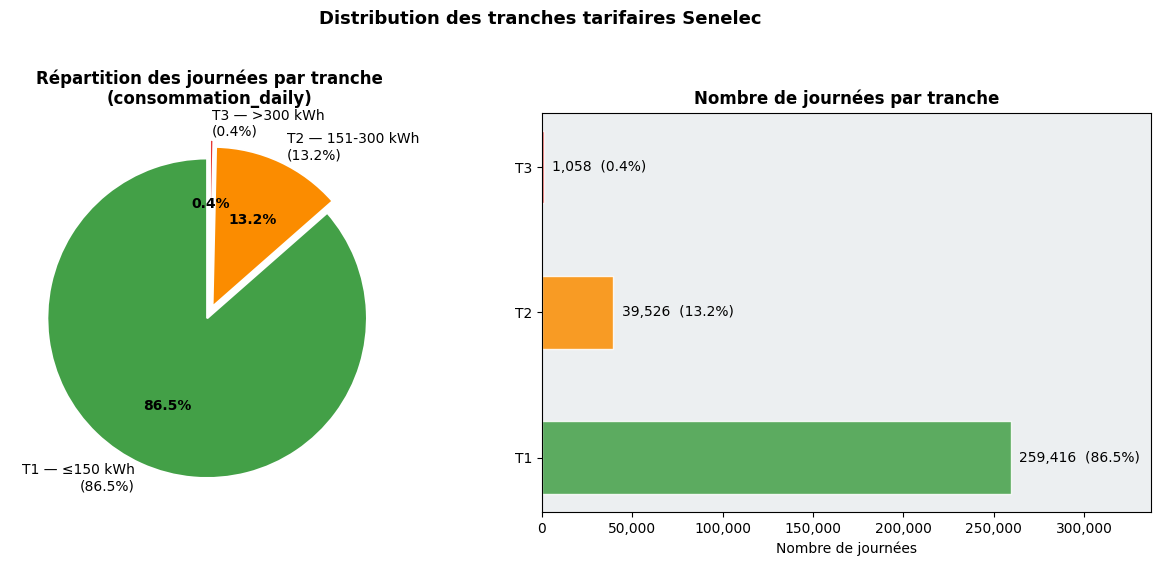

✅ Figure sauvegardée → reports/eda_tranches_T1_T2_T3.png


In [14]:
t_vals   = [tranches['1'], tranches['2'], tranches['3']]
t_labels = [
    f"T1 — ≤150 kWh\n({tranches['1']/total_lignes*100:.1f}%)",
    f"T2 — 151-300 kWh\n({tranches['2']/total_lignes*100:.1f}%)",
    f"T3 — >300 kWh\n({tranches['3']/total_lignes*100:.1f}%)",
]
t_colors  = ['#43A047', '#FB8C00', '#E53935']
t_explode = (0.04, 0.04, 0.08)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ── Camembert ─────────────────────────────────────────────────────────────────
wedges, texts, autotexts = axes[0].pie(
    t_vals, labels=t_labels, colors=t_colors, explode=t_explode,
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 10},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[0].set_title("Répartition des journées par tranche\n(consommation_daily)",
                  fontweight='bold', fontsize=12)

# ── Barres horizontales ───────────────────────────────────────────────────────
bars = axes[1].barh(['T1', 'T2', 'T3'], t_vals, color=t_colors, alpha=0.85,
                    edgecolor='white', height=0.5)
axes[1].bar_label(bars,
                  labels=[f"{v:,}  ({v/total_lignes*100:.1f}%)" for v in t_vals],
                  padding=6, fontsize=10)
axes[1].set_title("Nombre de journées par tranche", fontweight='bold', fontsize=12)
axes[1].set_xlabel("Nombre de journées")
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[1].set_facecolor('#ECEFF1')
axes[1].set_xlim(0, max(t_vals) * 1.3)

plt.suptitle("Distribution des tranches tarifaires Senelec", fontweight='bold',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../reports/eda_tranches_T1_T2_T3.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée → reports/eda_tranches_T1_T2_T3.png")


---

## 10. Machine Learning — Prédiction du dépassement de la Tranche 1

**Modèle :** Random Forest Classifier  
**Objectif :** prédire si un utilisateur va **dépasser la Tranche 1** (conso > 150 kWh/mois)  
**Features :**
- `cumul_mensuel` — consommation cumulée depuis le début du mois (kWh)
- `conso_recente_7j` — moyenne de consommation sur les 7 derniers jours (kWh/j)
- `conso_recente_3j` — moyenne de consommation sur les 3 derniers jours (kWh/j)
- `tranche_actuelle` — tranche tarifaire actuelle (1, 2 ou 3)
- `jours_restants` — jours restants dans le mois de facturation

**Cible :** `depassement_t1` (1 = dépasse T1, 0 = reste en T1)

In [18]:
%pip install -q scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [15]:
import random
from collections import defaultdict

random.seed(42)

# ── Construction du dataset ML depuis consumption_daily.csv ──────────────────
# On relit le fichier pour avoir user_id + date complète
records = []
with open(os.path.join(raw, 'consumption_daily.csv')) as f:
    for row in csv.DictReader(f):
        records.append({
            'user_id' : row['user_id'].strip(),
            'mois'    : int(row['mois'].strip()),
            'jour'    : int(row['jour'].strip()) if 'jour' in row else 0,
            'conso'   : float(row['conso_kwh']) if row['conso_kwh'] else 0,
            'tranche' : int(row['tranche'].strip()) if row['tranche'].strip().isdigit() else 1,
        })

# Trier par user, mois, jour
records.sort(key=lambda r: (r['user_id'], r['mois'], r['jour']))

# Construire les features par user×mois
X, y = [], []
user_mois = defaultdict(list)
for r in records:
    user_mois[(r['user_id'], r['mois'])].append(r)

for (uid, mois), jours in user_mois.items():
    total_mois = sum(j['conso'] for j in jours)
    n_jours    = len(jours)
    if n_jours < 5:          # ignorer les mois incomplets
        continue

    for i in range(4, n_jours):
        cumul     = sum(j['conso'] for j in jours[:i+1])
        rec7      = sum(j['conso'] for j in jours[max(0,i-6):i+1]) / min(7, i+1)
        rec3      = sum(j['conso'] for j in jours[max(0,i-2):i+1]) / min(3, i+1)
        tranche   = jours[i]['tranche']
        j_restant = n_jours - i - 1

        depassement = 1 if total_mois > 150 else 0

        X.append([cumul, rec7, rec3, tranche, j_restant])
        y.append(depassement)

print(f"Dataset ML : {len(X):,} échantillons")
print(f"  Dépassement T1 (y=1) : {sum(y):,} ({sum(y)/len(y)*100:.1f}%)")
print(f"  Reste en T1   (y=0)  : {len(y)-sum(y):,} ({(len(y)-sum(y))/len(y)*100:.1f}%)")
print(f"  Features : cumul_mensuel, conso_7j, conso_3j, tranche, jours_restants")


Dataset ML : 220,000 échantillons
  Dépassement T1 (y=1) : 103,180 (46.9%)
  Reste en T1   (y=0)  : 116,820 (53.1%)
  Features : cumul_mensuel, conso_7j, conso_3j, tranche, jours_restants


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

FEATURE_NAMES = ['cumul_mensuel', 'conso_7j', 'conso_3j', 'tranche', 'jours_restants']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"✅ Random Forest — Accuracy : {acc*100:.2f}%")
print()
print(classification_report(y_test, y_pred,
                             target_names=['Reste T1', 'Dépasse T1']))


✅ Random Forest — Accuracy : 98.19%

              precision    recall  f1-score   support

    Reste T1       0.98      0.98      0.98     23364
  Dépasse T1       0.98      0.98      0.98     20636

    accuracy                           0.98     44000
   macro avg       0.98      0.98      0.98     44000
weighted avg       0.98      0.98      0.98     44000



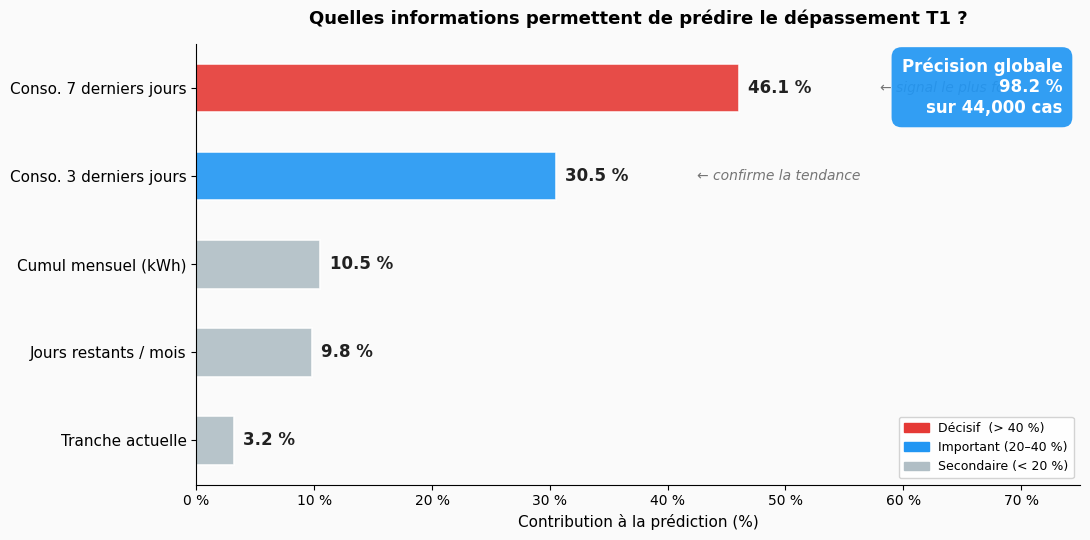

✅ Figure diapo sauvegardée → reports/ml_importance_slide.png


In [21]:
from matplotlib.patches import FancyBboxPatch
import matplotlib.patches as mpatches

importances  = rf.feature_importances_
sorted_idx   = sorted(range(len(importances)), key=lambda i: importances[i])
feat_labels  = {
    'cumul_mensuel'  : 'Cumul mensuel (kWh)',
    'conso_7j'       : 'Conso. 7 derniers jours',
    'conso_3j'       : 'Conso. 3 derniers jours',
    'tranche'        : 'Tranche actuelle',
    'jours_restants' : 'Jours restants / mois',
}
feat_sorted = [feat_labels[FEATURE_NAMES[i]] for i in sorted_idx]
imp_sorted  = [importances[i] * 100          for i in sorted_idx]   # en %

COLORS = ['#B0BEC5' if v < 20 else '#2196F3' if v < 40 else '#E53935'
          for v in imp_sorted]

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

bars = ax.barh(feat_sorted, imp_sorted, color=COLORS,
               alpha=0.90, edgecolor='white', linewidth=1.2, height=0.55)

# Valeurs directement sur les barres
for bar, val in zip(bars, imp_sorted):
    ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f} %', va='center', ha='left',
            fontsize=12, fontweight='bold',
            color='#212121')

# Annotations explicatives sur les 2 barres dominantes
dominant_idx = [i for i, v in enumerate(imp_sorted) if v >= 30]
messages = {
    imp_sorted.index(max(imp_sorted)): '← signal le plus fort',
    sorted(range(len(imp_sorted)), key=lambda i: imp_sorted[i])[-2]: '← confirme la tendance',
}
for idx, msg in messages.items():
    bar = bars[idx]
    ax.text(bar.get_width() + 12, bar.get_y() + bar.get_height() / 2,
            msg, va='center', ha='left', fontsize=10,
            color='#757575', fontstyle='italic')

ax.set_xlim(0, 75)
ax.set_xlabel("Contribution à la prédiction (%)", fontsize=11)
ax.set_title("Quelles informations permettent de prédire le dépassement T1 ?",
             fontweight='bold', fontsize=13, pad=14)
ax.tick_params(axis='y', labelsize=11)
ax.tick_params(axis='x', labelsize=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)} %"))
ax.spines[['top', 'right']].set_visible(False)

# Encadré résultat global en haut à droite
result_txt = f"Précision globale\n{acc*100:.1f} %\nsur {len(y_test):,} cas"
ax.text(0.98, 0.97, result_txt,
        transform=ax.transAxes, ha='right', va='top',
        fontsize=12, fontweight='bold', color='white',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#2196F3',
                  edgecolor='none', alpha=0.92))

# Légende couleurs
legend_handles = [
    mpatches.Patch(color='#E53935', label='Décisif  (> 40 %)'),
    mpatches.Patch(color='#2196F3', label='Important (20–40 %)'),
    mpatches.Patch(color='#B0BEC5', label='Secondaire (< 20 %)'),
]
ax.legend(handles=legend_handles, fontsize=9,
          loc='lower right', framealpha=0.85)

plt.tight_layout()
plt.savefig("../reports/ml_importance_slide.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure diapo sauvegardée → reports/ml_importance_slide.png")
